In [1]:
import os
import sys
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# 프로젝트 루트 디렉토리 설정
os.chdir("/home/youngjins/project/belief_trading")

# lib 하위 경로 추가
sys.path.append("/home/youngjins/project/belief_trading/lib/")
sys.path.append("/home/youngjins/project/belief_trading/lib/abides_jpmc_public")

# 환경 임포트
import gym
import abides_gym

# lib 모듈 임포트
from abides_core import abides
from abides_core.utils import parse_logs_df, ns_date, str_to_ns, fmt_ts
from abides_markets.configs import rmsc04
from lib.utils import print_state, gym_types

In [2]:
config = rmsc04.build_config()

# print key and value
for key, value in config.items():
    # if value is list, make empty dictionary for unique class name (key) and count number of elements (value)
    if isinstance(value, list):
        unique_classes = {}
        for v in value:
            class_name = v.__class__.__name__
            if class_name not in unique_classes:
                unique_classes[class_name] = 0
            unique_classes[class_name] += 1
        for class_name, count in unique_classes.items():
            print(f"{class_name}: {count}")
    else:
        print(f"{key}: {value}")

end_state = abides.run(config)  # simulation 실행

[9739] INFO abides Simulation Start Time: 2025-03-17 17:31:12.801509
[9739] INFO abides_core.kernel --- Simulation time: 2021-02-05 00:00:00, messages processed: 0, wallclock elapsed: 0.00s ---


seed: 2622996442
start_time: 1612483200000000000
stop_time: 1612519201000000000
ExchangeAgent: 1
NoiseAgent: 1000
ValueAgent: 102
AdaptiveMarketMakerAgent: 2
MomentumAgent: 12
agent_latency_model: <abides_core.latency_model.LatencyModel object at 0x7f9e0e7e2400>
default_computation_delay: 50
custom_properties: {'oracle': <abides_markets.oracles.sparse_mean_reverting_oracle.SparseMeanRevertingOracle object at 0x7f9e0ebd77c0>}
random_state_kernel: RandomState(MT19937)
stdout_log_level: INFO


[9739] INFO abides_core.kernel Event Queue elapsed: 0:00:02.181922, messages: 40,242, messages per second: 18443.4
[9739] INFO abides_core.kernel Mean ending value by agent type:
[9739] INFO abides_core.kernel NoiseAgent: -8
[9739] INFO abides_core.kernel ValueAgent: -359
[9739] INFO abides_core.kernel AdaptivePOVMarketMakerAgent: -8472
[9739] INFO abides_core.kernel MomentumAgent: 5098
[9739] INFO abides_core.kernel Simulation ending!
[9739] INFO abides Simulation End Time: 2025-03-17 17:31:16.239732
[9739] INFO abides Time taken to run simulation: 0:00:03.438223


/home/youngjins/miniconda3/envs/belief/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/home/youngjins/miniconda3/envs/belief/lib/python3.8/site-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/home/youngjins/miniconda3/envs/belief/lib/python3.8/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


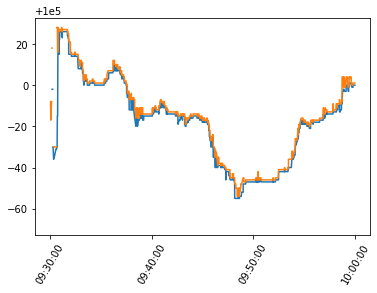

In [3]:
# 주문 orderbook 추출
order_book = end_state["agents"][0].order_books["ABM"]

# L1 주문 조회
L1 = order_book.get_L1_snapshots()
best_bids = pd.DataFrame(L1["best_bids"], columns=["time", "price", "qty"])
best_asks = pd.DataFrame(L1["best_asks"], columns=["time", "price", "qty"])

## All times are in ns from 1970, remove the date component to put them in ns from midnight
best_bids["time"] = best_bids["time"].apply(lambda x: x - ns_date(x))
best_asks["time"] = best_asks["time"].apply(lambda x: x - ns_date(x))

plt.plot(best_bids.time, best_bids.price)
plt.plot(best_asks.time, best_asks.price)

time_mesh = np.arange(str_to_ns("09:30:00"), str_to_ns("10:10:00"), 1e9 * 60 * 10)
_ = plt.xticks(
    time_mesh, [fmt_ts(time).split(" ")[1] for time in time_mesh], rotation=60
)

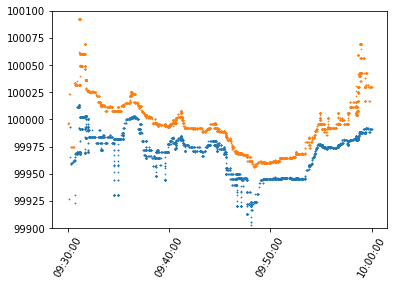

In [5]:
L2 = order_book.get_L2_snapshots(nlevels=30)

## plotting fifth best bid and fifth best ask
times = [t - ns_date(t) for t in L2["times"]]
plt.scatter(times, L2["bids"][:, 5, 0], s=0.5)
plt.scatter(times, L2["asks"][:, 5, 0], s=0.5)

band = 100
plt.ylim(100_000 - band, 100_000 + band)

_ = plt.xticks(
    time_mesh, [fmt_ts(time).split(" ")[1] for time in time_mesh], rotation=60
)